# 🚁 DIP Project — Gün 5: YOLOv8 Model Eğitimi
**Gereksinim:** Gün 2 tamamlanmış, VisDrone YOLO formatına dönüştürülmüş olmalı.

> Runtime → Change runtime type → **GPU (T4)**

## 0️⃣ GPU + Paket Kontrolü

In [2]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + list(args))

pip('numpy>=1.23,<2', '--force-reinstall')
pip('ultralytics==8.2.0', 'PyYAML')

print('=' * 55)
print('✅ Kurulum tamam!')
print()
print('  >>> Runtime > Restart Runtime yap <<<')
print('  Restart sonrası bu hücreyi ATLA, sonrakinden başla!')
print('=' * 55)

✅ Kurulum tamam!

  >>> Runtime > Restart Runtime yap <<<
  Restart sonrası bu hücreyi ATLA, sonrakinden başla!


In [2]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 1️⃣ Google Drive + Yollar

In [1]:
# ▶️ Restart sonrası buradan başla
import torch, os
from ultralytics import YOLO

assert torch.cuda.is_available(), '❌ GPU bulunamadı! Runtime > GPU seç.'
print(f'✅ GPU  : {torch.cuda.get_device_name(0)}')
print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/DIP_Project (1)'
YAML_PATH   = f'{PROJECT_DIR}/data.yaml'
RUNS_DIR    = f'{PROJECT_DIR}/runs'
os.makedirs(RUNS_DIR, exist_ok=True)

assert os.path.exists(YAML_PATH), f'❌ {YAML_PATH} bulunamadı — Gün 2 çalıştırıldı mı?'
print(f'✅ data.yaml: {YAML_PATH}')

import yaml
with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)
print(f'   Dataset : {cfg["path"]}')
print(f'   Sınıf   : {cfg["nc"]} → {cfg["names"]}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ GPU  : Tesla T4
   VRAM: 15.6 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ data.yaml: /content/drive/MyDrive/DIP_Project (1)/data.yaml
   Dataset : /content/drive/MyDrive/DIP_Project/datasets/VisDrone
   Sınıf   : 10 → ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']


In [4]:
import os
# Kendi klasör yoluna göre düzenle
klasor_yolu = '/content/drive/MyDrive/DIP_Project (1)'
print(os.listdir(klasor_yolu))

['notebooks', 'datasets', 'sahi_comparison.png', 'sahi_best_result.png', 'slice_grid.png', 'mosaic_example.png', 'augmentation_grid.png', 'runs', 'data.yaml']


## 2️⃣ Dataset Kontrolü — Eğitim Başlamadan Önce

In [9]:
from pathlib import Path

# cfg['path'] yerine doğrudan doğru klasör yolunu belirtiyoruz
DATASET_ROOT = '/content/drive/MyDrive/DIP_Project (1)/datasets/VisDrone'

splits = {'train': 0, 'val': 0, 'test-dev': 0}
for split in splits:
    img_dir = Path(DATASET_ROOT) / 'images' / split

    if img_dir.exists():
        splits[split] = len(list(img_dir.glob('*.jpg')))

    print(f'  [{split:>8}] {splits[split]:>5} görüntü — {img_dir}')

assert splits['train'] > 0, '❌ Train seti boş — Gün 2 dönüşüm scriptini çalıştır!'
assert splits['val']   > 0, '❌ Val seti boş!'
print('\n✅ Dataset hazır!')

  [   train]  6471 görüntü — /content/drive/MyDrive/DIP_Project (1)/datasets/VisDrone/images/train
  [     val]   548 görüntü — /content/drive/MyDrive/DIP_Project (1)/datasets/VisDrone/images/val
  [test-dev]     0 görüntü — /content/drive/MyDrive/DIP_Project (1)/datasets/VisDrone/images/test-dev

✅ Dataset hazır!


In [12]:
YAML_PATH = '/content/drive/MyDrive/DIP_Project (1)/data.yaml'
RUNS_DIR  = '/content/drive/MyDrive/DIP_Project (1)/runs'


## 3️⃣ YOLOv8s Eğitimi — 50 Epoch, Batch 16
Tahmini süre: T4 GPU'da ~3–5 saat

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics>=8.3.0'])
print('✅ ultralytics güncellendi')


✅ ultralytics güncellendi


In [4]:
import yaml

PROJECT_DIR = '/content/drive/MyDrive/DIP_Project (1)'
DATASET_DIR = f'{PROJECT_DIR}/datasets/VisDrone'

data_config = {
    'path': DATASET_DIR,
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test-dev',
    'nc': 10,
    'names': ['pedestrian','people','bicycle','car','van',
              'truck','tricycle','awning-tricycle','bus','motor'],
}

YAML_PATH = f'{PROJECT_DIR}/data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False, allow_unicode=True)

print(f'✅ data.yaml güncellendi')
print(open(YAML_PATH).read())


✅ data.yaml güncellendi
names:
- pedestrian
- people
- bicycle
- car
- van
- truck
- tricycle
- awning-tricycle
- bus
- motor
nc: 10
path: /content/drive/MyDrive/DIP_Project (1)/datasets/VisDrone
test: images/test-dev
train: images/train
val: images/val



In [ ]:
from ultralytics import YOLO
import time

YAML_PATH = '/content/drive/MyDrive/DIP_Project (1)/data.yaml'
RUNS_DIR  = '/content/drive/MyDrive/DIP_Project (1)/runs'

model = YOLO('yolov8s.pt')

def on_train_epoch_end(trainer):
    e    = trainer.epoch + 1
    loss = trainer.loss.item() if hasattr(trainer.loss, 'item') else float(trainer.loss)
    lr   = trainer.optimizer.param_groups[0]['lr']
    print(f'Epoch {e:>3}/{trainer.epochs}  |  loss: {loss:.4f}  |  lr: {lr:.6f}')

def on_val_end(trainer):
    m = trainer.metrics
    try:
        map50   = m.box.map50
        map5095 = m.box.map
        print(f'         → mAP@50: {map50:.4f}  |  mAP@50:95: {map5095:.4f}')
    except Exception:
        pass  # ilk epoch warmup sırasında metrics henüz dolu olmayabilir

model.add_callback('on_train_epoch_end', on_train_epoch_end)
model.add_callback('on_val_end', on_val_end)

results = model.train(
    data          = YAML_PATH,
    epochs        = 50,
    batch         = 32,
    imgsz         = 640,
    device        = 0,
    workers       = 8,
    project       = RUNS_DIR,
    name          = 'yolov8s_visdrone_v1',
    exist_ok      = True,
    patience      = 15,
    mosaic        = 1.0,
    close_mosaic  = 10,
    lr0           = 0.01,
    lrf           = 0.01,
    warmup_epochs = 3,
    save          = True,
    save_period   = 10,
    val           = True,
    verbose       = False,
)

print('\n✅ Eğitim tamamlandı!')
print(f'   Best model: {results.save_dir}/weights/best.pt')


Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIP_Project (1)/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_visdrone_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

In [2]:
from ultralytics import YOLO
import glob

PROJECT_DIR = '/content/drive/MyDrive/DIP_Project (1)'
YAML_PATH   = f'{PROJECT_DIR}/data.yaml'
RUNS_DIR    = f'{PROJECT_DIR}/runs'

# last.pt'yi bul
pts = glob.glob(f'{PROJECT_DIR}/runs/**/last.pt', recursive=True)
if not pts:
    pts = glob.glob('/content/drive/**/*visdrone*/weights/last.pt', recursive=True)

if not pts:
    print('❌ last.pt bulunamadı — baştan başlamak gerekiyor')
else:
    LAST_PT = pts[0]
    print(f'✅ Devam: {LAST_PT}')

    model = YOLO(LAST_PT)

    def on_train_epoch_end(trainer):
        e    = trainer.epoch + 1
        loss = trainer.loss.item() if hasattr(trainer.loss, 'item') else float(trainer.loss)
        lr   = trainer.optimizer.param_groups[0]['lr']
        print(f'Epoch {e:>3}/{trainer.epochs}  |  loss: {loss:.4f}  |  lr: {lr:.6f}')

    def on_val_end(trainer):
        try:
            m = trainer.metrics
            print(f'         → mAP@50: {m.box.map50:.4f}  |  mAP@50:95: {m.box.map:.4f}')
        except Exception:
            pass

    model.add_callback('on_train_epoch_end', on_train_epoch_end)
    model.add_callback('on_val_end', on_val_end)

    results = model.train(
        data         = YAML_PATH,
        epochs       = 50,
        batch        = 16,
        imgsz        = 640,
        device       = 0,
        workers      = 4,
        project      = RUNS_DIR,
        name         = 'yolov8s_visdrone_v1',
        exist_ok     = True,
        patience     = 15,
        mosaic       = 1.0,
        close_mosaic = 10,
        save         = True,
        save_period  = 10,
        val          = True,
        verbose      = False,
        resume       = True,
    )

    print('\n✅ Eğitim tamamlandı!')
    print(f'   Best model: {results.save_dir}/weights/best.pt')


✅ Devam: /content/drive/MyDrive/DIP_Project (1)/runs/yolov8s_visdrone_v1/weights/last.pt
Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DIP_Project (1)/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/DIP_Project (1)/runs/yolov8s_visdrone

In [8]:
import shutil, os

shortcut = '/content/drive/.shortcut-targets-by-id'
for root, dirs, files in os.walk(shortcut):
    for f in files:
        if f.endswith('.cache'):
            src = os.path.join(root, f)
            print(f'Bulundu: {src}')


Bulundu: /content/drive/.shortcut-targets-by-id/10qz2Me8vqCDxUGp_Aoo5uNwzs54LtdpY/DIP_Project/datasets/VisDrone/labels/train.cache
Bulundu: /content/drive/.shortcut-targets-by-id/10qz2Me8vqCDxUGp_Aoo5uNwzs54LtdpY/DIP_Project/datasets/VisDrone/labels/val.cache


## 4️⃣ Learning Curve — Loss & mAP Grafikleri

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0    lr/pg1    lr/pg2
45     46  7146.74         1.26472         0.78260         0.86698               0.51166            0.38938           0.38083              0.21987       1.32915       0.90985       0.87786  0.000078  0.000078  0.000078
46     47  7335.20         1.25851         0.77786         0.86496               0.52094            0.38854           0.38138              0.21997       1.32691       0.90919       0.87824  0.000064  0.000064  0.000064
47     48  7524.49         1.25676         0.77360         0.86612               0.51414            0.39063           0.37991              0.21987       1.32967       0.91083       0.87881  0.000050  0.000050  0.000050
48     49  7718.31         1.25540         0.76734         0.86477               0.52327            0.38923           0.3804

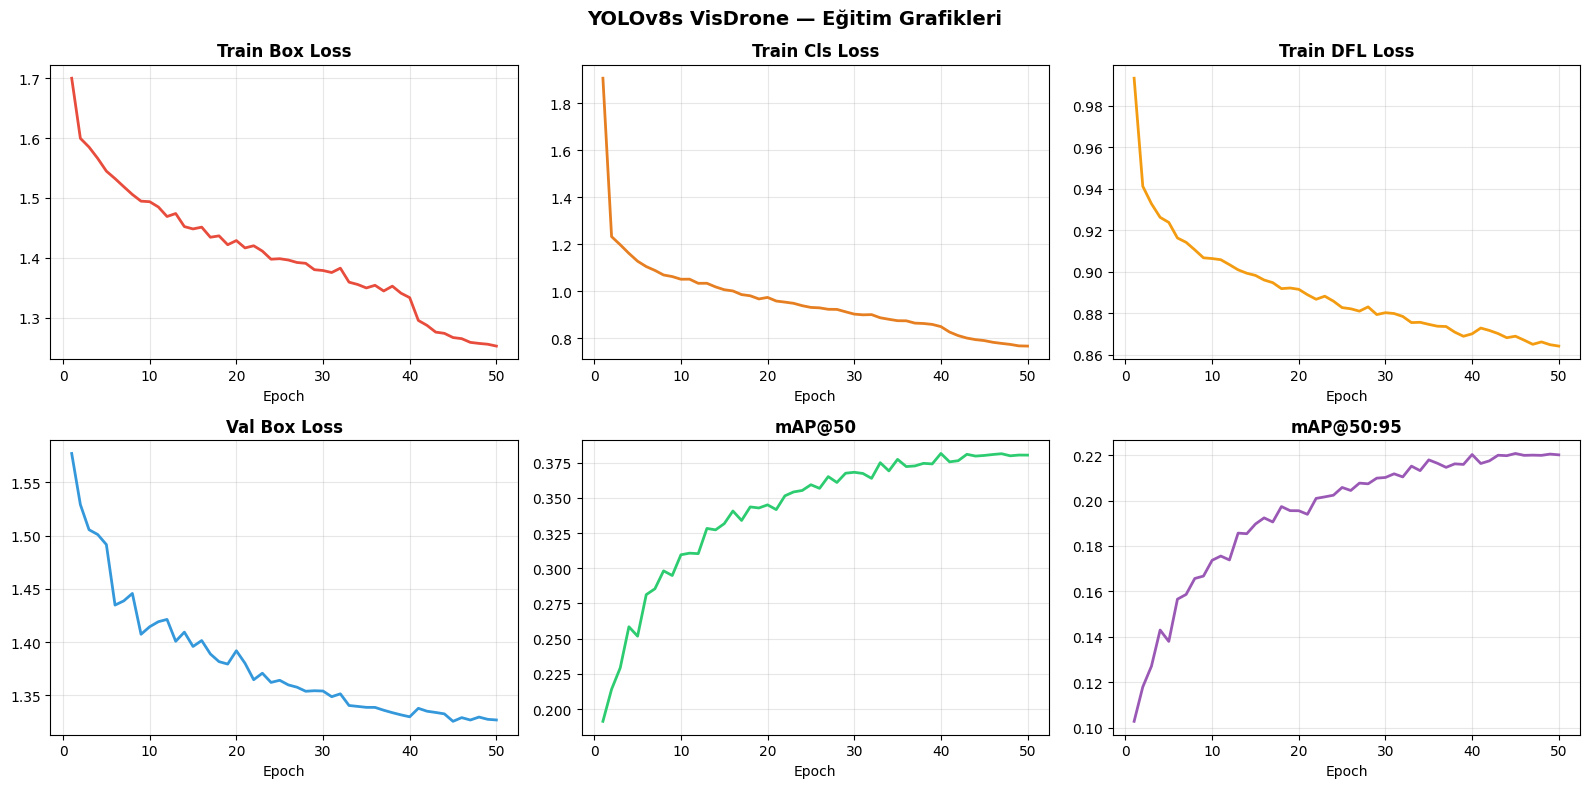

✅ Kaydedildi: /content/drive/MyDrive/DIP_Project (1)/training_curves.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path(RUNS_DIR) / 'yolov8s_visdrone_v1'
csv_path = run_dir / 'results.csv'

assert csv_path.exists(), f'❌ {csv_path} bulunamadı'
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
print(df.tail(5).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics = [
    ('train/box_loss', 'Train Box Loss', '#e74c3c'),
    ('train/cls_loss', 'Train Cls Loss', '#e67e22'),
    ('train/dfl_loss', 'Train DFL Loss', '#f39c12'),
    ('val/box_loss',   'Val Box Loss',   '#3498db'),
    ('metrics/mAP50(B)',   'mAP@50',     '#2ecc71'),
    ('metrics/mAP50-95(B)','mAP@50:95',  '#9b59b6'),
]
for ax, (col, title, color) in zip(axes.flat, metrics):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=2)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{col}\nnot found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

plt.suptitle('YOLOv8s VisDrone — Eğitim Grafikleri', fontsize=14, fontweight='bold')
plt.tight_layout()
out = f'{PROJECT_DIR}/training_curves.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Kaydedildi: {out}')

## 5️⃣ Best Model Yolunu Kaydet

In [4]:
import json

best_pt = str(run_dir / 'weights' / 'best.pt')
last_pt = str(run_dir / 'weights' / 'last.pt')

info = {
    'best_model': best_pt,
    'last_model': last_pt,
    'run_dir':    str(run_dir),
    'yaml':       YAML_PATH,
}
meta_path = f'{PROJECT_DIR}/model_paths.json'
with open(meta_path, 'w') as f:
    json.dump(info, f, indent=2)

print('✅ Model yolları kaydedildi:')
for k, v in info.items():
    print(f'   {k}: {v}')
print('\n✅ GÜN 5 TAMAMLANDI!')

✅ Model yolları kaydedildi:
   best_model: /content/drive/MyDrive/DIP_Project (1)/runs/yolov8s_visdrone_v1/weights/best.pt
   last_model: /content/drive/MyDrive/DIP_Project (1)/runs/yolov8s_visdrone_v1/weights/last.pt
   run_dir: /content/drive/MyDrive/DIP_Project (1)/runs/yolov8s_visdrone_v1
   yaml: /content/drive/MyDrive/DIP_Project (1)/data.yaml

✅ GÜN 5 TAMAMLANDI!


---
## ✅ Gün 5 Özet
| Parametre | Değer |
|-----------|-------|
| Model | YOLOv8s (pretrained COCO) |
| Epoch | 50 + patience=15 |
| Batch | 16 |
| imgsz | 640 |
| Mosaic | 1.0 (son 10 epoch kapalı) |
| Checkpoint | Her 10 epochta |

**Sonraki (Gün 7):** ByteTrack entegrasyonu → `day7_bytetrack.ipynb`